# GRU

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Data analysis

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/NEW_Bitcoin_data_full.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
data.head()

,open,high,low,close,Volume BTC,Volume USD,sentiment_score
date,,,,,,,
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00,2390398.89,273.58,0.506941
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49,7986062.84,917.79,0.433762
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32,1593991.98,182.62,0.000000
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90,11101273.74,1260.69,0.374867
2018-05-15 11:00:00,8795.90,8821.19,8740.54,8760.00,2842987.30,324.11,0.393823


In [4]:
data.describe()

,open,high,low,close,Volume BTC,Volume USD,sentiment_score
count,49936.000000,49936.000000,49936.000000,49936.000000,4.993600e+04,4.993600e+04,49936.000000
mean,22743.227033,22850.586565,22628.390846,22743.885549,1.073828e+06,2.767733e+06,0.247624
std,16270.719788,16356.844258,16177.630638,16270.876263,2.643497e+06,6.316341e+06,0.230800
min,3139.760000,3158.340000,3122.280000,3139.760000,0.000000e+00,0.000000e+00,-0.984411
25%,8343.410000,8381.157500,8310.520000,8343.410000,5.901332e+01,2.814150e+02,0.000000
50%,19371.015000,19440.965000,19287.960000,19370.220000,2.414339e+02,6.391276e+05,0.319934
75%,34756.122500,34970.000000,34548.197500,34752.035000,1.130458e+06,2.929618e+06,0.451585
max,68635.050000,69000.000000,68447.000000,68627.010000,6.857061e+07,2.582324e+08,0.846238


In [5]:
# The number of missing values 
data.isna().sum()

open               0
high               0
low                0
close              0
Volume BTC         0
Volume USD         0
sentiment_score    0
dtype: int64

## Data processing

In [6]:
# Train-val-test split (70% training, 15% validation, 15% test)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Compute split indices
train_index = int(len(data) * train_ratio)
val_index = train_index + int(len(data) * val_ratio)

# Perform the splits
train_data = data.iloc[:train_index]                    # First 70% for training
val_data = data.iloc[train_index:val_index]             # Next 15% for validation
test_data = data.iloc[val_index:]                       # Final 15% for testing

# Print the shapes to confirm
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (34955, 7)
Validation shape: (7490, 7)
Test shape: (7491, 7)


In [7]:
print("Train start:", train_data.index[0], "end:", train_data.index[-1])
print("Val start:", val_data.index[0], "end:", val_data.index[-1])
print("Test start:", test_data.index[0], "end:", test_data.index[-1])

Train start: 2018-05-15 07:00:00 end: 2022-05-10 17:00:00
Val start: 2022-05-10 18:00:00 end: 2023-03-18 19:00:00
Test start: 2023-03-18 20:00:00 end: 2024-01-24 22:00:00


In [8]:
# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit only on training data

# Transform train, validation, and test data using the fitted scaler
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)  

In [9]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [10]:
# Define window size and target column
window_size = 24 # past 24h (short-term market behavior)
target_col = 'close'
target_col_idx = data.columns.get_loc(target_col)

# Create sequences for training, validation and test sets
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)
X_test, y_test = create_sequences(test_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(34931, 24, 7) (34931,)
(7466, 24, 7) (7466,)
(7467, 24, 7) (7467,)


## Model training (GRU)

In [11]:
# Define GRU model
gru_model = Sequential([
    GRU(60, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(1) # Predicting the close price
])
gru_model.compile(optimizer=Adam(), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60)             │        12,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,481 (48.75 KB)

 Trainable params: 12,481 (48.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0363 - val_loss: 2.7469e-05
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0024 - val_loss: 1.5707e-05
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0017 - val_loss: 1.4562e-05
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0014 - val_loss: 1.7567e-05
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0013 - val_loss: 1.0837e-05
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - val_loss: 1.4470e-05
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - val_loss: 1.2621e-05
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0010 - val_loss: 1.1074e-05
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0010 - val_loss: 1.3781e-05
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.4182e-04 - val_loss: 2.1469e-05
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.9281e-04 - val_loss: 

In [13]:
# Training and validation loss
history.history.keys()

dict_keys(['loss', 'val_loss'])

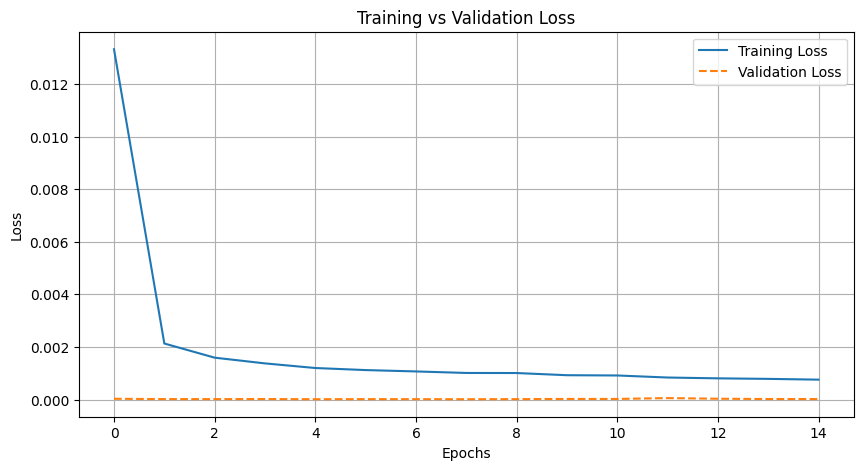

In [14]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation 

In [15]:
# Crate an inverse function
def inverse_transform_predictions(predicted_scaled, y_actual_scaled, scaler, train_data, target_col_idx):
    """
    Inverse transforms the scaled predictions and actual values back to the original scale.

    Parameters:
    - predicted_scaled: Model predictions in scaled form (shape: (n_samples, 1)).
    - y_actual_scaled: Actual target values in scaled form (shape: (n_samples,)).
    - scaler: The MinMaxScaler fitted on the training data.
    - train_data: The original training dataset (used to get the number of features for inverse transform).
    - target_col_idx: The index of the target column in the dataset.

    Returns:
    - predicted_inverse: Predictions in the original scale.
    - y_actual_inverse: Actual values in the original scale.
    """

    # Create full arrays with the same shape as train_data for inverse transformation
    predicted_full = np.zeros((predicted_scaled.shape[0], train_data.shape[1]))
    y_actual_full = np.zeros((y_actual_scaled.shape[0], train_data.shape[1]))

    # Fill only the target column ('close' price)
    predicted_full[:, target_col_idx] = predicted_scaled[:, 0]  # Ensure correct shape
    y_actual_full[:, target_col_idx] = y_actual_scaled  # y_actual is already 1D

    # Apply inverse transform
    predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
    y_actual_inverse = scaler.inverse_transform(y_actual_full)[:, target_col_idx]

    return predicted_inverse, y_actual_inverse

### Training set evaluation 

In [16]:
# Get inverse transformed predictions and actual values
predicted_train_inverse, y_train_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_train),
    y_actual_scaled=y_train,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [17]:
# Compute error metrics for the training set
mae_train = mean_absolute_error(y_train_inverse, predicted_train_inverse)
rmse_train = sqrt(mean_squared_error(y_train_inverse, predicted_train_inverse))
mape_train = np.mean(np.abs((y_train_inverse - predicted_train_inverse) / y_train_inverse)) * 100  

print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAPE: {mape_train:.2f}%")

Train MAE: 246.5133
Train RMSE: 357.7772
Train MAPE: 1.92%


### Validation set evaluation 

In [18]:
# Get inverse transformed predictions and actual values
predicted_val_inverse, y_val_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_val),
    y_actual_scaled=y_val,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [19]:
# Compute error metrics for the val set
mae_val = mean_absolute_error(y_val_inverse, predicted_val_inverse)
rmse_val = sqrt(mean_squared_error(y_val_inverse, predicted_val_inverse))
mape_val = np.mean(np.abs((y_val_inverse - predicted_val_inverse) / y_val_inverse)) * 100  

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAPE: {mape_val:.2f}%")

Validation MAE: 143.1039
Validation RMSE: 215.5811
Validation MAPE: 0.67%


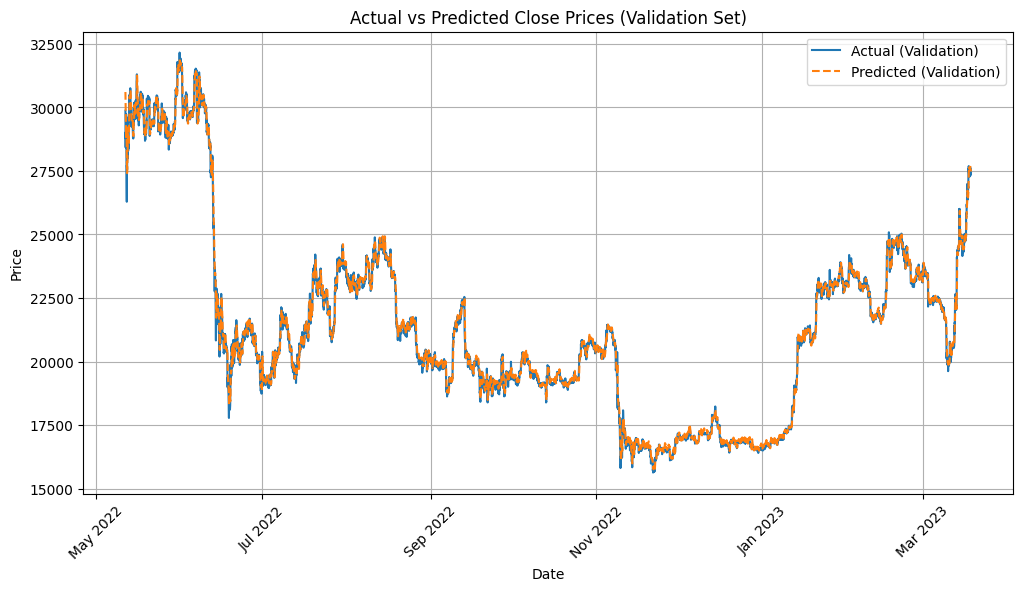

In [20]:
# Extract date index for plotting
date_index = val_data.index[window_size:]  # Align with sequence offset

# Plot actual vs predicted close prices for validation set
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='Predicted (Validation)', linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Benchmark against a Naïve Forecast

In [21]:
val_data.head()

,open,high,low,close,Volume BTC,Volume USD,sentiment_score
date,,,,,,,
2022-05-10 18:00:00,31677.56,31779.23,31423.49,31609.07,217.015342,6.859653e+06,0.400505
2022-05-10 19:00:00,31624.70,31688.06,31204.86,31323.69,178.403606,5.588259e+06,0.369110
2022-05-10 20:00:00,31316.37,31345.74,30921.59,31000.17,197.898073,6.134874e+06,0.421059
2022-05-10 21:00:00,30987.42,31144.56,30239.10,30239.10,299.214532,9.047978e+06,0.318306
2022-05-10 22:00:00,30231.85,30942.29,30167.96,30760.53,261.350934,8.039293e+06,0.467907


In [22]:
actual_val = val_data['close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_val.iloc[window_size - 1:-1].values
actual_val_values = actual_val.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_val_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_val_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_val_values - naive_predictions) / actual_val_values)) * 100

print(f"Validation Naive MAE: {mae_naive:.4f}")
print(f"Validation Naive RMSE: {rmse_naive:.4f}")
print(f"Validation Naive MAPE: {mape_naive:.2f}%")

Validation Naive MAE: 85.1331
Validation Naive RMSE: 144.3645
Validation Naive MAPE: 0.39%


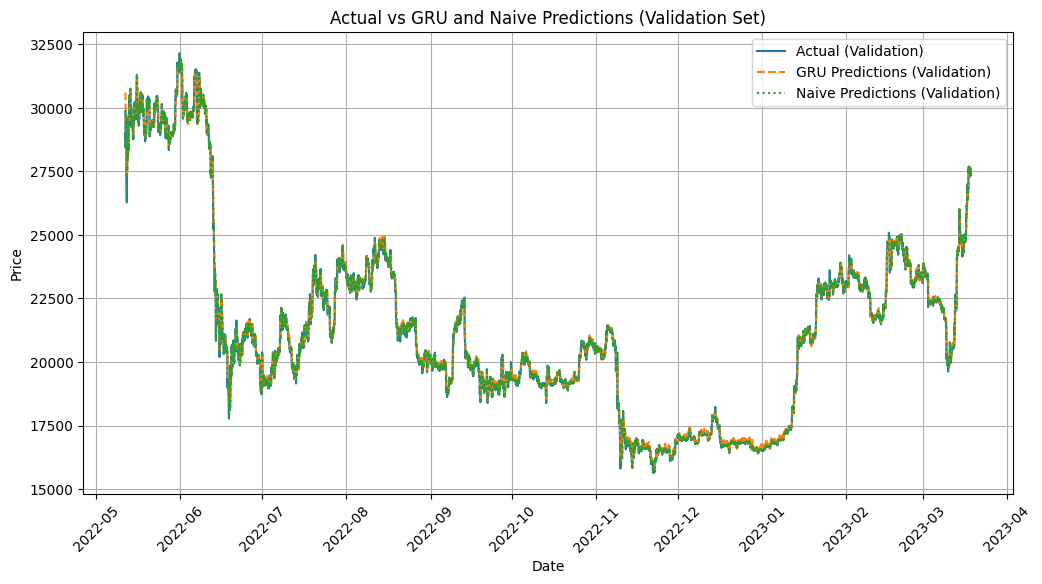

In [23]:
# Prepare a date index for plotting (adjusting for the sequence offset)
date_index = val_data.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='GRU Predictions (Validation)', linestyle='dashed')
plt.plot(date_index, naive_predictions, label='Naive Predictions (Validation)', linestyle='dotted')
plt.title('Actual vs GRU and Naive Predictions (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()